# 1D Burgers Equation DEMO code

This notebook demonstrates solving 1D Burgers Equation (spatial xy version) using PINNs.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain

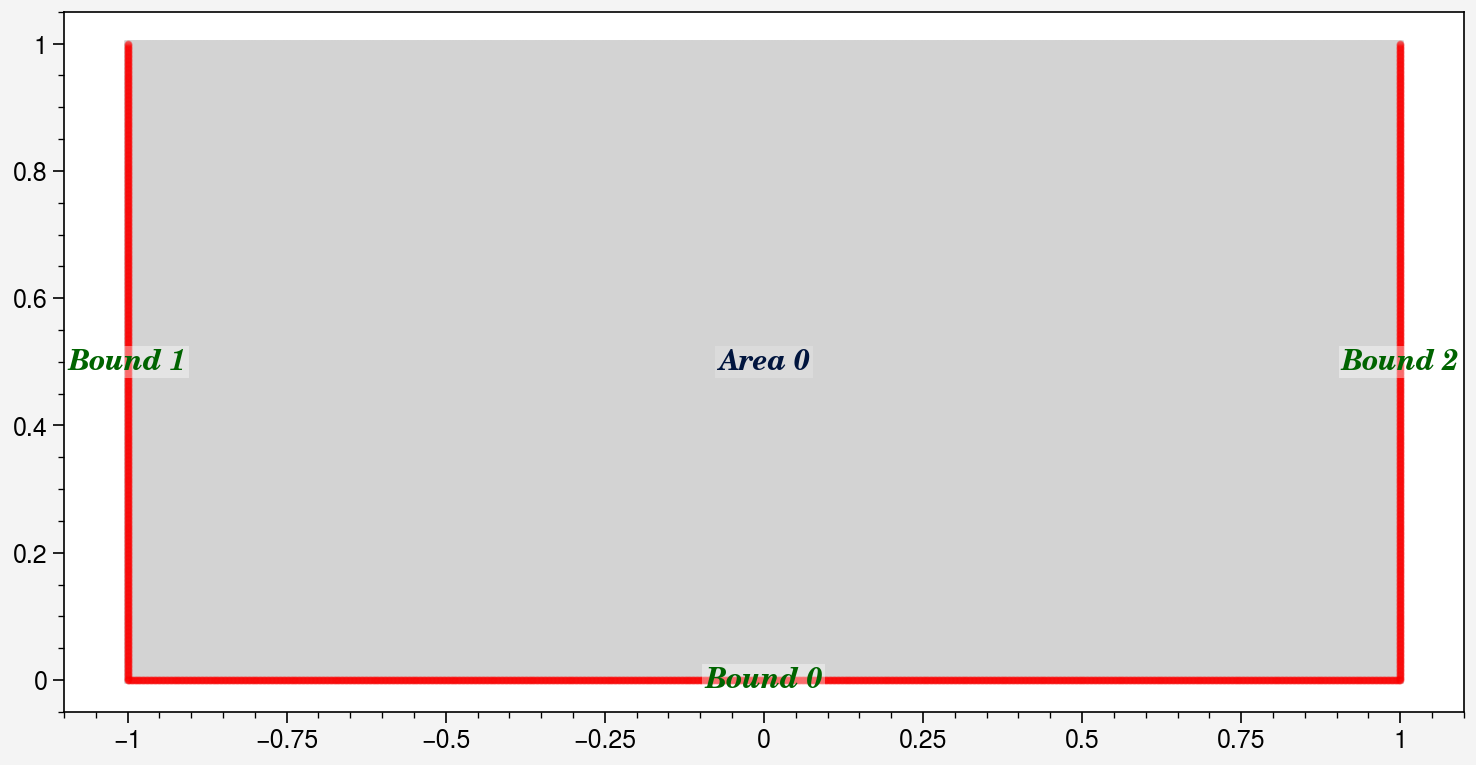

In [2]:
area = df.geometry.rectangle([-1, 1], [0, 1])
line_ic = df.geometry.line_horizontal(y=0, range_x=[-1,1])
line_bc1 = df.geometry.line_vertical(x=-1, range_y=[0,1])
line_bc2 = df.geometry.line_vertical(x=1, range_y=[0,1])
domain = df.domain(area.area_list, line_ic, line_bc1, line_bc2)
domain.show_setup()

## 2. Define Physics
Define the Burgers eq (spatial version) apply boundary conditions.

In [3]:
# Define PDE
from torch import sin, pi
domain.area_list[0].define_pde(df.pde.BurgersEquation1D(nu=0.01/pi))
domain.bound_list[0].define_bc({'u':['x', lambda x: -sin(pi * x)]})
domain.bound_list[1].define_bc({'u': 0})
domain.bound_list[2].define_bc({'u': 0})

### 2. Generate Training Data

Sample initial points for training. After sampling, Deepflow will automatically generate training datasets based on the defined physics.

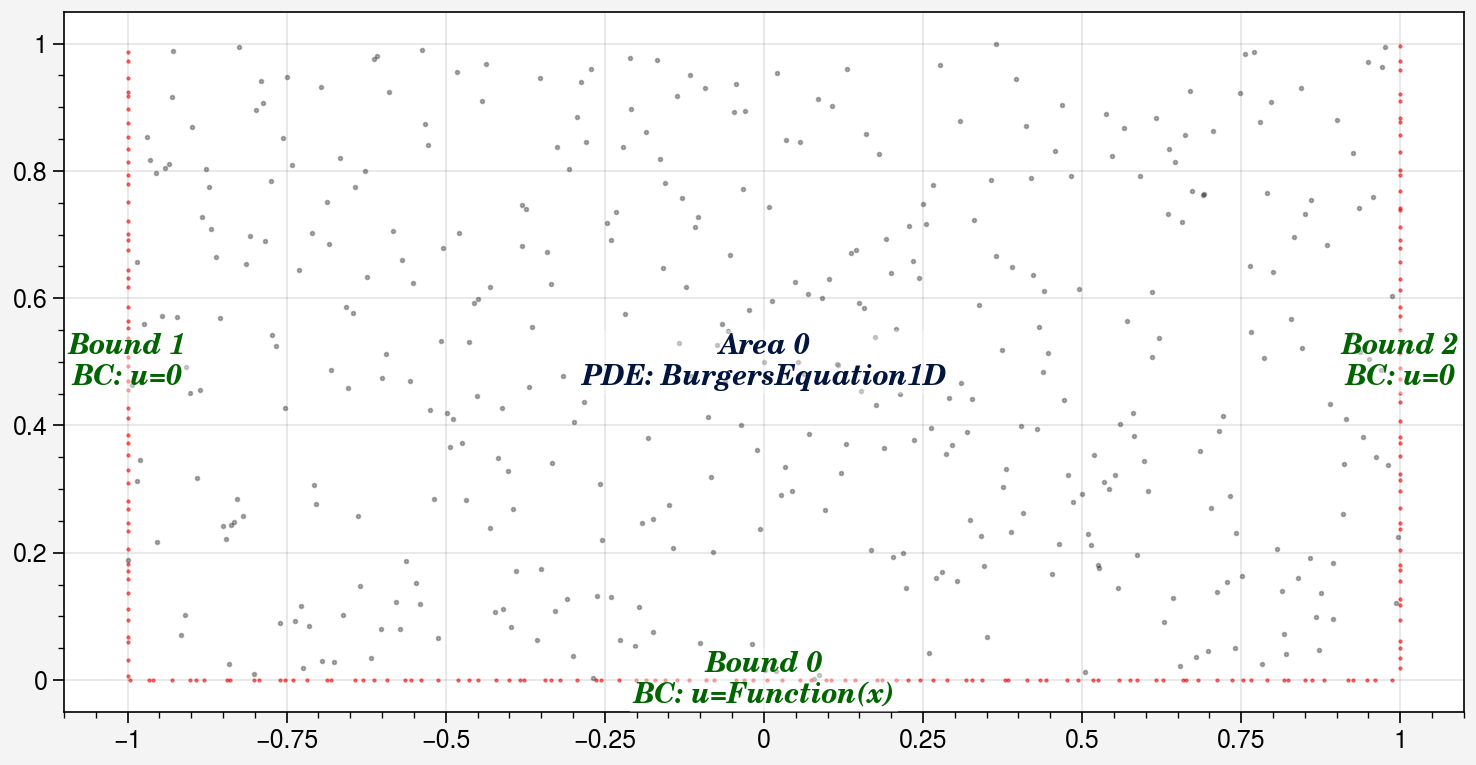

In [4]:
# Sample points: [Left, Bottom, Right, Top], [Interior]
domain.sampling_lhs([100, 50, 50], [400])
domain.show_coordinates(display_physics=True)

### 3. Train the Model

Define the resampling scheme during training. [R3](https://arxiv.org/abs/2207.02338) scheme is recommended.

In [ ]:
def do_in_adam(epoch, model):
    if epoch % 100 == 0 and epoch > 0:
        domain.sampling_lhs([100, 50, 50], [400])
        #domain.sampling_R3([200, 100, 100], [400])
        print(domain)
        
def do_in_lbfgs(epoch, model):
    if epoch % 50 == 0 and epoch > 0:
        domain.sampling_lhs([100, 50, 50], [400])
        #domain.sampling_R3([200, 100, 100], [400])
        print(domain)

Train the model using Adam optimizer followed by L-BFGS optimizer.

In [6]:
model0 = df.QCPINN(input_vars=['x','y'], output_vars=['u'], hidden_layer_pre=[50], hidden_layer_post=[50], nqubits=5)

model1, model1_best = model0.train_adam(
    calc_loss = df.calc_loss_simple(domain),
    learning_rate=0.004,
    epochs=1000,
    do_between_epochs=do_in_adam)

Epoch: 1, total_loss: 0.86226, bc_loss: 0.86195, pde_loss: 0.00031
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Epoch: 200, total_loss: 0.11118, bc_loss: 0.06785, pde_loss: 0.04332
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Epoch: 400, total_loss: 0.10544, bc_loss: 0.06246, pde_loss: 0.04298
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Epoch: 600, total_loss: 0.08764, bc_loss: 0.05331, pde_loss: 0.03433
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Epoch: 800, total_loss: 0.09291, bc_loss: 0.05653, pde_loss: 0.03638
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Epoch: 1000, total_loss: 0.07453, bc_loss: 0.04549, pde_loss: 0.02904
Epoch: 1000, total_loss: 0.07453, bc_loss: 0.04549, pde_loss: 0.02904


In [9]:
model2 = model1.train_lbfgs(
    calc_loss = df.calc_loss_simple(domain), 
    epochs=300, 
    do_between_epochs=do_in_lbfgs,
)

Epoch: 1001, total_loss: 0.07189, bc_loss: 0.04235, pde_loss: 0.02954
Epoch: 1051, total_loss: 0.02226, bc_loss: 0.00770, pde_loss: 0.01456
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Epoch: 1101, total_loss: 0.01373, bc_loss: 0.00837, pde_loss: 0.00536
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Epoch: 1151, total_loss: 0.00824, bc_loss: 0.00433, pde_loss: 0.00391
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Epoch: 1201, total_loss: 0.00502, bc_loss: 0.00334, pde_loss: 0.00168
number of bound : ['0: 100', '1: 50', '2: 50']
number of area : ['0: 400']
Detected NaN in loss. Stop the training.
Detected NaN in loss. Stop the training.
Detected NaN in loss. Stop the training.
Detected NaN in loss. Stop the training.
Detected NaN in loss. Stop the training.
Detected NaN in loss. Stop the training.
Detected NaN in loss. Stop the training.
Detected NaN in loss. Stop the training.
Detected NaN in loss. 

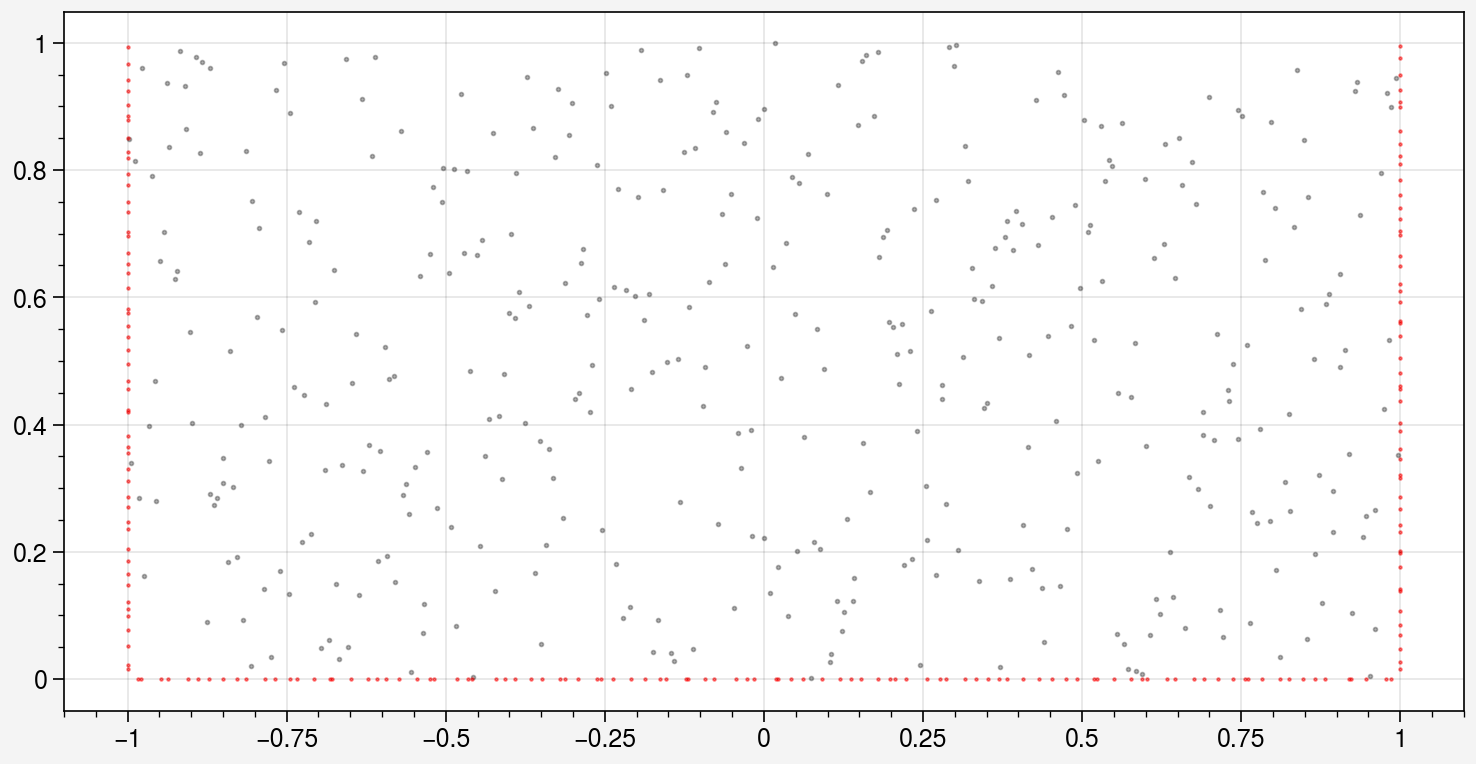

In [10]:
domain.show_coordinates(display_physics=False)

## 4. Visualization

In [11]:
# Evaluate the best model
prediction = domain.area_list[0].evaluate(model2)
# Sampling uniform points
prediction.sampling_area([500, 250])

### 4.1 Visualize PDE area

TypeError: '<' not supported between instances of 'float' and 'NoneType'

Error in callback <function _draw_all_if_interactive at 0x0000016762C2E2A0> (for post_execute), with arguments args (),kwargs {}:


TypeError: '<' not supported between instances of 'float' and 'NoneType'

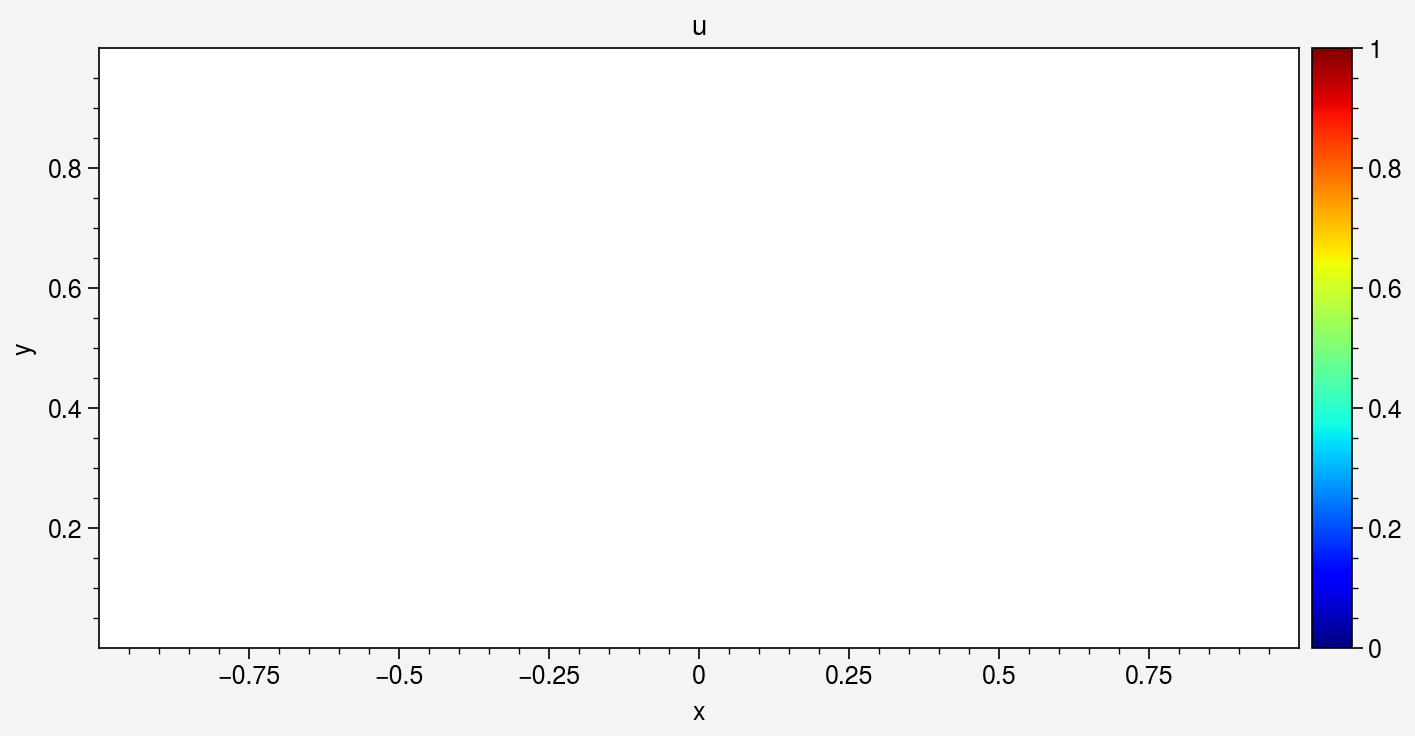

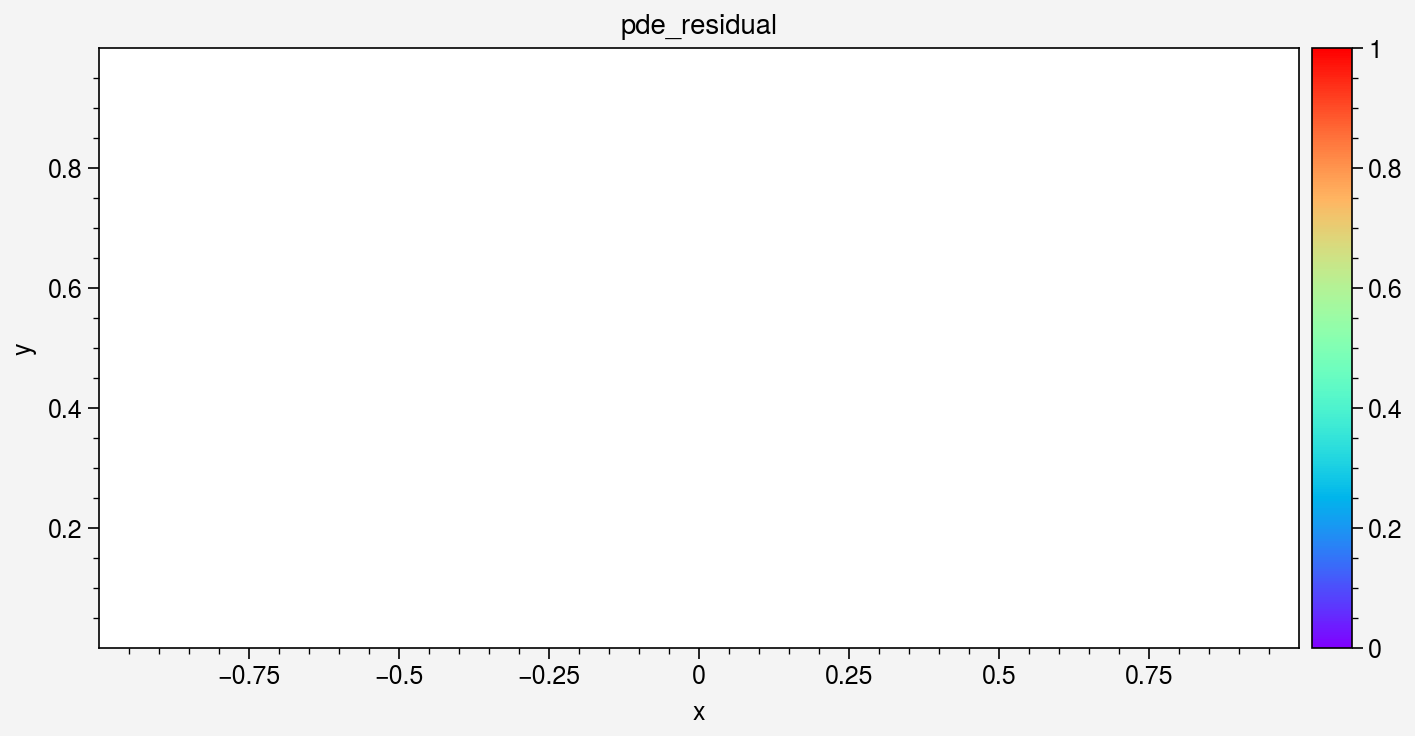

TypeError: '<' not supported between instances of 'float' and 'NoneType'

Figure(nrows=1, ncols=1, refwidth=np.float64(6.0))

In [12]:
# Plot Velocity Field
prediction.plot_color('u', cmap = 'jet', s=0.3).savefig('u_field.png')
_ = prediction.plot_color('pde_residual', cmap = 'rainbow', s=0.3)
_ = prediction.plot('pde_residual')
_ = prediction.plot_loss_curve(log_scale=True)

### 4.2 Visualize u at y = 0.75

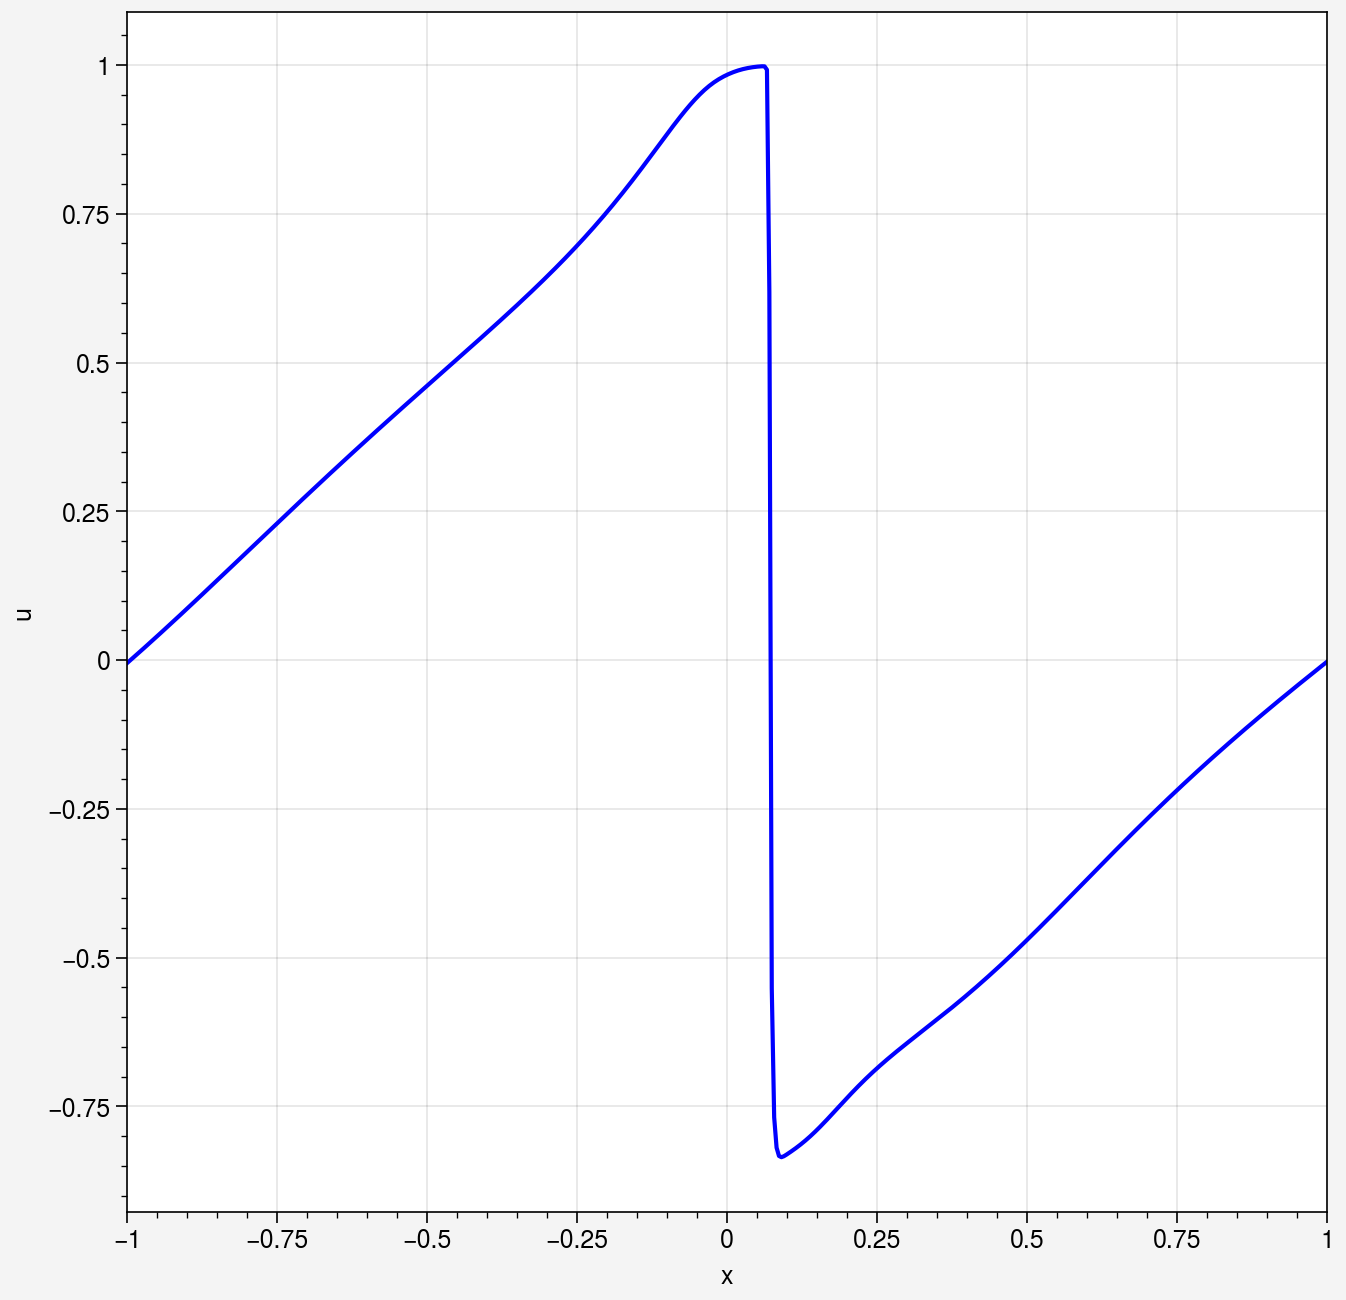

In [ ]:
line = df.geometry.line_horizontal(y=0.75, range_x=[-1, 1])
prediction = line.evaluate(model2)
prediction.sampling_line(500)
_ = prediction.plot(y_axis = 'u')